In [1]:
pip install diffusers transformers accelerate safetensors

In [2]:
#import the library
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
#load the stable diffusion model from hugging face
pipe=StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype=torch.float16).to('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


enter the prompt herea cyberpunk portrait of a woman, neon lights, rain, ultra detailed, 4k


  0%|          | 0/50 [00:00<?, ?it/s]

image saved as generated_image.png


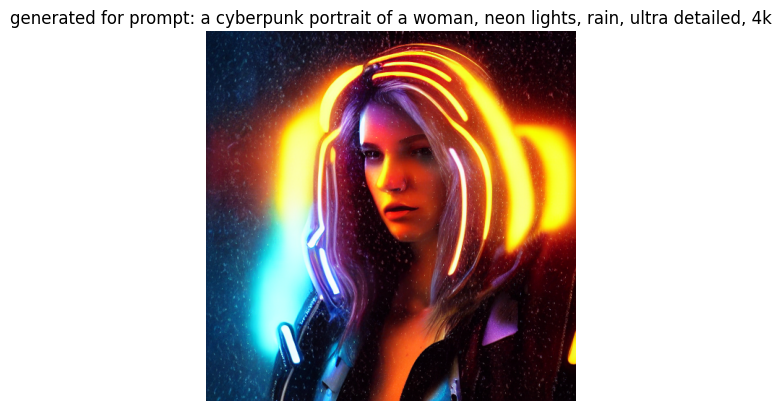

In [6]:
prompt=input('enter the prompt here')
#generate the image using the user's prompt
with torch.autocast('cuda'):
  image=pipe(prompt).images[0]   #prompt-->text encoder--->diffusion(noise->image)--->VAE decoder--->pil image
#save the image to a file
image.save('generated_image.png')
print('image saved as generated_image.png')
#display the image
plt.imshow(image)
plt.axis('off')
plt.title(f'generated for prompt: {prompt}')
plt.show()
